# XM655 self interference cancellation

Cancel system 0's own signal out of its receivers, and measure how much of it
went away - on the board, not on paper.

- **BSIC** beamforms around the interference: transmit weights that spill little
  on our own receivers, receive weights that hear little of what is left.
- **DSIC** fits the known transmit waveform to what BSIC left and subtracts it,
  after the ADC - so a saturated front end stays saturated.

One sided bench: **only system 0 cancels**. System 1 transmits a tone of its own
so that there is a link to preserve and an SIR to quote, but it never beamforms
and never cancels its own leakage - it is a signal source and a far field probe.

Two tones, one FFT: system 0's tone inside system 0's receiver is the
interference, system 1's tone inside the same receiver is the wanted signal, and
they sit on different bins so a single capture measures both.

The stored channels only **design** BSIC. Every reported number is **measured**,
over six aligned captures, so estimation error shows up instead of hiding.

BSIC lives in `lib/fd/non_joint_sic_bsic.py`, DSIC in `lib/fd/dsic.py`.

## 1. Parameters

Everything that gets tuned. Nothing outside this cell should need editing.

The RF block and the four system lists must match the estimation run - section 2
checks them against the stored `params.json`.

System 0 is the one this notebook cancels for. System 1 transmits its own tone on
flat weights from the first capture to the last, except in the two training
captures where it is muted on purpose.

In [1]:
from lib.config_parser import load_config

CFG = load_config()
TEST_MODE = CFG["test_mode"]   # the software board of lib/mts, no ZCU216 needed

# --- system 0: the node this notebook cancels for ---
DACS_0 = CFG["systems"]["dacs_0"]    # overlay.dac[] indices, tile 2
ADCS_0 = CFG["systems"]["adcs_0"]    # its own receivers - the near field, tile 1

# --- system 1: the far node, transmitting but never cancelling ---
DACS_1 = CFG["systems"]["dacs_1"]    # overlay.dac[] indices, tile 3 - flat weights
ADCS_1 = CFG["systems"]["adcs_1"]    # its receivers - the far field, tile 0

# --- the estimated channels bsic is designed on ---
CHANNELS_DIR = "output/channels"     # where channel_estimation.ipynb left them

# --- rf: must match the estimation run, checked below ---
DAC_NCO  = CFG["rf"]["dac_nco"]      # MHz, per tile -> TX lands at 4900
DAC_ZONE = CFG["rf"]["dac_zone"]     # Nyquist zone, per tile
ADC_NCO  = CFG["rf"]["adc_nco"]      # MHz, per tile = 5000 - DAC_NCO
ADC_ZONE = CFG["rf"]["adc_zone"]     # the fold is in an even zone

# --- rates: fixed by the bitstream, do not change ---
DAC_SR = CFG["board"]["dac_sr"]      # DAC baseband rate = 10 GSPS / 10 (C2R eats one x2)
ADC_SR = CFG["board"]["adc_sr"]      # ADC baseband rate = 2.5 GSPS / 10 decimation
N_CH   = CFG["board"]["n_ch"]        # RF channels on the XM655
N_TILE = CFG["board"]["n_tile"]      # ADC and DAC tiles

PATH_PER_TILE = N_CH // N_TILE       # converters per tile - one player memory each

# --- one tone per system, so the FFT can tell the leakage from the link ---
CW_TONE_0_MHZ = CFG["signal"]["tone_0_mhz"]  # system 0 transmits this - what we cancel
CW_TONE_1_MHZ = CFG["signal"]["tone_1_mhz"]  # system 1 transmits this - what we preserve
CW_AMP        = CFG["signal"]["amp"]       # 14 bit DAC: +16383 / -16384

# --- bsic: which beamforming canceller, and what it needs ---
BSIC_ALGORITHM = "non_joint_max_sinr"   # see lib/fd/non_joint_sic_bsic.py
SNR_DB        = 40         # the transmission against the board's own noise floor
BSIC_MAX_GAIN = 1.0        # ceiling on any element gain, the register allows 2.0
SIDE_1_GAIN   = 1.0        # system 1 drives flat at this - drop it if ADCS_1 saturates
MAX_PHASE_DEG = 179.99     # the converter rejects exactly 180, so clamp to this

# --- dsic: which digital canceller, and what it needs ---
DSIC_ALGORITHM = "linear_lms"           # see lib/fd/dsic.py
DSIC_TAPS    = 1           # delays the fit is allowed, per receiver
DSIC_MU      = 1e-3        # lms step: larger converges faster and settles noisier
DSIC_TRAIN_N = 16384       # preamble length: DSIC_MU * this is how far it settles

# --- one block of samples ---
N_CAP       = CFG["capture"]["n_cap"]        # samples per channel
TRIG_HOLD_S = CFG["capture"]["trig_hold_s"]  # trig_cap must stay high for a whole capture window

# --- where this run is written ---
SIC_DIR = "output/sic"

## 2. Verify the parameters

Catch a bad settings cell before anything touches the board, and confirm the
stored matrices were measured on *this* array at *this* frequency.

`snap_tone_to_fft_bin()` overrides a parameter instead of rejecting it: every
power below is read off a single FFT bin, so both tones have to land on one - and
on bins of their own, or the leakage and the link cannot be told apart.

In [2]:
import json
import os
import time

import numpy as np

from lib.fd.non_joint_sic_bsic import BSIC_ALGORITHMS
from lib.fd.non_joint_sic_bsic import solve_matched_direction
from lib.fd.dsic import DSIC_ALGORITHMS
from lib.common_functions import capture_aligned
from lib.common_functions import clear_dir
from lib.common_functions import convert_raw_to_iq
from lib.common_functions import create_tone_samples
from lib.common_functions import find_tone_bin
from lib.common_functions import save_json_params
from lib.common_functions import snap_tone_to_fft_bin
from lib.common_functions import tune_adcs
from lib.common_functions import tune_dacs
from lib.common_functions import write_tone_to_tile_player

def select_algorithm(name, algorithms, kind):
    """Look a name up in one of the lib dictionaries, or list what was on offer."""
    if name not in algorithms:
        raise ValueError("%r is not a %s algorithm. Valid names: %s"
                         % (name, kind, ", ".join(algorithms)))
    return algorithms[name]

def validate_systems():
    """Both systems are complete and disjoint, and each transmits from one DAC tile.

    The tile check is what makes two tones possible: there is one player memory per
    tile and all four of its DACs read it, so a system sending its own waveform has
    to sit inside a tile of its own.
    """
    for name, indices in (("DACS_0", DACS_0), ("ADCS_0", ADCS_0),
                          ("DACS_1", DACS_1), ("ADCS_1", ADCS_1)):
        if len(indices) == 0:
            raise ValueError("%s is empty - both systems transmit here" % name)
        if not set(indices) <= set(range(N_CH)):
            raise ValueError("%s holds indices outside 0..%d" % (name, N_CH - 1))
        if len(set(indices)) != len(indices):
            raise ValueError("%s lists the same index twice" % name)
    shared_dacs = set(DACS_0) & set(DACS_1)
    if shared_dacs:
        raise ValueError("DACs %s are listed under both systems" % sorted(shared_dacs))
    shared_adcs = set(ADCS_0) & set(ADCS_1)
    if shared_adcs:
        raise ValueError("ADCs %s are listed under both systems" % sorted(shared_adcs))
    tile_of = {}
    for name, dacs in (("DACS_0", DACS_0), ("DACS_1", DACS_1)):
        tiles = sorted(set(dac // PATH_PER_TILE for dac in dacs))
        if len(tiles) != 1:
            raise ValueError("%s spans DAC tiles %s - there is one player memory per "
                             "tile, so a system sending its own tone must sit inside one"
                             % (name, tiles))
        tile_of[name] = tiles[0]
    if tile_of["DACS_0"] == tile_of["DACS_1"]:
        raise ValueError("both systems transmit from DAC tile %d - they would share "
                         "one player memory and could not send different tones"
                         % tile_of["DACS_0"])

def validate_rf_settings():
    """Converter tables are per tile, the folds add up, and both tones fit the band.

    A tone at 4905 comes back at 95, so the two NCOs sum to twice the converter rate.
    """
    for name, table in (("DAC_NCO", DAC_NCO), ("DAC_ZONE", DAC_ZONE),
                        ("ADC_NCO", ADC_NCO), ("ADC_ZONE", ADC_ZONE)):
        if len(table) != N_TILE:
            raise ValueError("%s needs one entry per tile (%d), got %d"
                             % (name, N_TILE, len(table)))
    fold_mhz = 2 * (10 * ADC_SR / 1e6)
    for tile, (dac_nco, adc_nco) in enumerate(zip(DAC_NCO, ADC_NCO)):
        if abs(dac_nco + adc_nco - fold_mhz) > 1e-6:
            raise ValueError("tile %d: ADC_NCO should be %g - DAC_NCO"
                             % (tile, fold_mhz))
    for name, tone_mhz in (("CW_TONE_0_MHZ", CW_TONE_0_MHZ),
                           ("CW_TONE_1_MHZ", CW_TONE_1_MHZ)):
        if not 0 < tone_mhz < ADC_SR / 2e6:
            raise ValueError("%s must be between 0 and %g, got %g"
                             % (name, ADC_SR / 2e6, tone_mhz))
    if not 0 < CW_AMP <= 16383:
        raise ValueError("CW_AMP must be between 1 and 16383")
    if N_CAP <= 0 or N_CAP & (N_CAP - 1):
        raise ValueError("N_CAP must be a positive power of two, got %d" % N_CAP)
    if TRIG_HOLD_S <= 0:
        raise ValueError("TRIG_HOLD_S must be positive")

def validate_tone_separation():
    """The two tones sit on bins of their own, or neither can be read alone."""
    bin_0 = find_tone_bin(CW_TONE_0_MHZ, N_CAP, ADC_SR)
    bin_1 = find_tone_bin(CW_TONE_1_MHZ, N_CAP, ADC_SR)
    if bin_0 == bin_1:
        raise ValueError("both tones land on FFT bin %d - they must differ by at least "
                         "one bin of the %g Hz grid" % (bin_0, ADC_SR / N_CAP))
    print("system 0: %.6f MHz on bin %d | system 1: %.6f MHz on bin %d | %d bins apart"
          % (CW_TONE_0_MHZ, bin_0, CW_TONE_1_MHZ, bin_1, abs(bin_1 - bin_0)))

def validate_algorithms():
    """Both algorithm names resolve, their settings are sane, and say what they buy.

    Resolved here so a typo in the parameter cell is caught before the board is touched.
    """
    select_algorithm(BSIC_ALGORITHM, BSIC_ALGORITHMS, "BSIC")
    select_algorithm(DSIC_ALGORITHM, DSIC_ALGORITHMS, "DSIC")
    if SNR_DB <= 0:
        raise ValueError("SNR_DB must be positive, got %g" % SNR_DB)
    if not 0 < SIDE_1_GAIN <= 2.0:
        raise ValueError("SIDE_1_GAIN must be between 0 and 2.0, got %g"
                         % SIDE_1_GAIN)
    if not 0 < BSIC_MAX_GAIN <= 2.0:
        raise ValueError("BSIC_MAX_GAIN must be between 0 and 2.0, got %g"
                         % BSIC_MAX_GAIN)
    if not 90.0 <= MAX_PHASE_DEG < 180.0:
        raise ValueError("MAX_PHASE_DEG must be just under 180, got %g" % MAX_PHASE_DEG)
    if DSIC_TAPS < 1:
        raise ValueError("DSIC_TAPS must be at least 1, got %d" % DSIC_TAPS)
    if DSIC_MU <= 0:
        raise ValueError("DSIC_MU must be positive, got %g" % DSIC_MU)
    if DSIC_TRAIN_N < DSIC_TAPS:
        raise ValueError("DSIC_TRAIN_N %d is shorter than DSIC_TAPS %d"
                         % (DSIC_TRAIN_N, DSIC_TAPS))
    if DSIC_TRAIN_N > N_CAP:
        raise ValueError("DSIC_TRAIN_N %d is longer than the block, N_CAP is %d"
                         % (DSIC_TRAIN_N, N_CAP))
    settling_db = -20 * np.log10(np.exp(-DSIC_MU * DSIC_TRAIN_N))
    print("bsic: %s over %d element(s), designed for %g dB SNR"
          % (BSIC_ALGORITHM, len(DACS_0), SNR_DB))
    print("dsic: %s, %d tap(s), step %g over %d sample(s) - the taps walk to "
          "within %.0f dB of the channel"
          % (DSIC_ALGORITHM, DSIC_TAPS, DSIC_MU, DSIC_TRAIN_N, settling_db))

def validate_stored_channels():
    """The matrices have to be there, the right shape, and from this exact setup."""
    if not os.path.isdir(CHANNELS_DIR):
        raise FileNotFoundError("%s does not exist - run channel_estimation.ipynb to "
                                "measure the channels first" % CHANNELS_DIR)
    for name in ("h00.npy", "h01.npy", "h10.npy", "params.json"):
        path = os.path.join(CHANNELS_DIR, name)
        if not os.path.isfile(path):
            raise FileNotFoundError("%s is missing - run channel_estimation.ipynb to "
                                    "measure the channels first" % path)
    wanted = {"h00.npy": (len(ADCS_0), len(DACS_0)),
              "h01.npy": (len(ADCS_0), len(DACS_1)),
              "h10.npy": (len(ADCS_1), len(DACS_0))}
    for name, expected in wanted.items():
        shape = np.load(os.path.join(CHANNELS_DIR, name)).shape
        if shape != expected:
            raise ValueError("%s has shape %s, this array wants %s"
                             % (name, shape, expected))
    with open(os.path.join(CHANNELS_DIR, "params.json")) as handle:
        stored = json.load(handle)
    for key, mine in (("dacs_0", DACS_0), ("adcs_0", ADCS_0),
                      ("dacs_1", DACS_1), ("adcs_1", ADCS_1),
                      ("dac_nco", DAC_NCO), ("adc_nco", ADC_NCO)):
        if list(stored[key]) != list(mine):
            raise ValueError("%s: the stored channels say %s, this notebook says %s"
                             % (key, stored[key], mine))
    if abs(stored["cw_tone_mhz"] - CW_TONE_0_MHZ) > 1e-9:
        raise ValueError("the stored channels were measured at %g MHz, not %g MHz"
                         % (stored["cw_tone_mhz"], CW_TONE_0_MHZ))
    print("channels from %s, measured at %.6f MHz - system 1 transmits %.6f MHz away"
          % (CHANNELS_DIR, stored["cw_tone_mhz"],
             abs(CW_TONE_1_MHZ - stored["cw_tone_mhz"])))

validate_systems()
validate_rf_settings()
CW_TONE_0_MHZ = snap_tone_to_fft_bin(CW_TONE_0_MHZ, ADC_SR, N_CAP)
CW_TONE_1_MHZ = snap_tone_to_fft_bin(CW_TONE_1_MHZ, ADC_SR, N_CAP)
validate_tone_separation()
validate_algorithms()
validate_stored_channels()

print("parameters ok - system 0: DAC %s ADC %s | system 1: DAC %s ADC %s"
      % (DACS_0, ADCS_0, DACS_1, ADCS_1))
print("algorithms available - bsic: %s | dsic: %s"
      % (", ".join(BSIC_ALGORITHMS), ", ".join(DSIC_ALGORITHMS)))

tone 5 -> 5.004883 MHz, nearest bin of the 15258.8 Hz grid
tone 5.5 -> 5.493164 MHz, nearest bin of the 15258.8 Hz grid
system 0: 5.004883 MHz on bin 328 | system 1: 5.493164 MHz on bin 360 | 32 bins apart
bsic: non_joint_max_sinr over 4 element(s), designed for 40 dB SNR
dsic: linear_lms, 1 tap(s), step 0.001 over 16384 sample(s) - the taps walk to within 142 dB of the channel
channels from output/channels, measured at 5.004883 MHz - system 1 transmits 0.488281 MHz away
parameters ok - system 0: DAC [8, 9, 10, 11] ADC [4, 5, 6, 7] | system 1: DAC [12, 13, 14, 15] ADC [0, 1, 2, 3]
algorithms available - bsic: non_joint_max_sinr, non_joint_zf, non_joint_softnull_max_sinr_based | dsic: linear_wiener, linear_lms, non_linear_lms, non_linear_wiener


## 3. Load the estimated channels

Three of the four matrices are used here. `H11` is system 1 talking to itself and
has nothing to do with our cancellation.

| key | matrix | path | shape |
|---|---|---|---|
| `si` | `H00` | our DACs -> our own ADCs, the interference | `(len(ADCS_0), len(DACS_0))` |
| `downlink` | `H10` | our DACs -> the far node, the wanted direction | `(len(ADCS_1), len(DACS_0))` |
| `uplink` | `H01` | the far node -> our ADCs, what we listen along | `(len(ADCS_0), len(DACS_1))` |

These design the beamformer and nothing else - the depth further down is measured.

The eigenvalues of `H00^H H00` printed here are **the ceiling on what BSIC can
do**: a near zero one is a direction that barely leaks, all of them within a few
dB means nowhere quiet to stand and no transmit weight helps.

Fewer receivers than transmit elements *guarantees* somewhere to hide. As many
receivers as elements guarantees nothing - which is what the print is for.

In [3]:
def load_estimated_channels():
    """The three channel matrices the beamformer is designed against."""
    si = np.load(os.path.join(CHANNELS_DIR, "h00.npy"))
    downlink = np.load(os.path.join(CHANNELS_DIR, "h10.npy"))
    uplink = np.load(os.path.join(CHANNELS_DIR, "h01.npy"))
    return {"si": si, "downlink": downlink, "uplink": uplink}

def describe_channels(channels):
    """One line per matrix and the beamformer headroom, before anything uses them.

    Eigenvalues are clipped at zero and the quietest floored, so a true null stays
    a finite number of dB instead of a division by a solver rounding error.
    """
    for name, matrix in channels.items():
        print("%-9s %s  |h| min %.4g  max %.4g"
              % (name, matrix.shape, np.abs(matrix).min(), np.abs(matrix).max()))
    eigenvalues = np.maximum(np.linalg.eigvalsh(channels["si"].conj().T
                                                @ channels["si"]), 0.0)
    quietest = max(eigenvalues[0], eigenvalues[-1] * 1e-12)
    print("H00^H H00 eigenvalues: %s"
          % np.array2string(eigenvalues, precision=4, suppress_small=True))
    print("bsic headroom: about %.1f dB between the quietest direction and the "
          "loudest" % (10 * np.log10(eigenvalues[-1] / quietest)))

CHANNELS = load_estimated_channels()
describe_channels(CHANNELS)


si        (4, 4)  |h| min 0.09996  max 0.09996
downlink  (4, 4)  |h| min 0.09996  max 0.09996
uplink    (4, 4)  |h| min 0.09996  max 0.09996
H00^H H00 eigenvalues: [0.0003 0.0241 0.0552 0.0803]
bsic headroom: about 24.6 dB between the quietest direction and the loudest


## 4. BSIC - beamforming cancellation

`BSIC_ALGORITHM` picks the beamformer out of the lib. Three vectors come out, and
only one of them is hardware:

| | weights | where it lives |
|---|---|---|
| `tx` | `DACS_0` | the gain and phase registers, one per DAC |
| `nf_rx` | `ADCS_0` | a complex sum in numpy, straight after the capture |
| `ff_rx` | `ADCS_1` | the same, over the far node's channels |

| name | transmit | receive |
|---|---|---|
| `non_joint_max_sinr` | most wanted power per unit of leakage | the same, along the uplink, against the leakage it picks up |
| `non_joint_zf` | strongest direction of `H10` | strongest direction of `H01`, with `H00 @ tx` projected out - an exact null |

Neither loops: the transmit weight never depends on the receive one. `SNR_DB` only
loads the max sinr denominator, the zero forcing one ignores it.

Both sides are now measured. The transmit weight is scored on `H10`, the receive
weight on `H01` - there is no longer an assumption that the wanted signal comes
back down the paths it went out on.

`ff_rx` is a plain match to wherever the transmitter ended up pointing. We own
those ADCs on this bench and combining them is free.

In [4]:
def run_bsic(channels):
    """Hand the measured channels to the chosen beamformer and take its weights.

    The noise power is the board floor against the unit power transmission, so the
    array is not spent nulling a direction already under it.
    """
    algorithm = select_algorithm(BSIC_ALGORITHM, BSIC_ALGORITHMS, "BSIC")
    noise_power = 10 ** (-SNR_DB / 10)
    weights = algorithm(channels["si"], channels["downlink"], channels["uplink"],
                        noise_power)
    return weights

def create_uniform_weights(channels):
    """Every element driven and heard equally - the reference BSIC has to beat.

    The far field combine is still matched: it costs nothing and is not the thing
    under test, so leaving it uniform would flatter the beamformer.
    """
    elements = channels["si"].shape[1]
    receivers = channels["si"].shape[0]
    tx = np.ones(elements, dtype=complex) / np.sqrt(elements)
    nf_rx = np.ones(receivers, dtype=complex) / np.sqrt(receivers)
    ff_rx = solve_matched_direction(channels["downlink"] @ tx)
    return {"tx": tx, "nf_rx": nf_rx, "ff_rx": ff_rx}

def create_hardware_weights(tx_weights):
    """System 0 beamformed, system 1 flat - the gain and phase tables the DACs take.

    The ceiling scales system 0 as a whole and not each element, because the beam
    lives in the ratios between them. System 1 never beamforms, so all of its
    elements sit at SIDE_1_GAIN with no phase - the one knob that backs its
    drive off if its own leakage saturates its own receivers.
    """
    gains = [0.0] * N_CH
    phases = [0.0] * N_CH
    scaled = tx_weights * (BSIC_MAX_GAIN / np.max(np.abs(tx_weights)))
    for element, dac in enumerate(DACS_0):
        degrees = (np.rad2deg(np.angle(scaled[element])) + 180.0) % 360.0 - 180.0
        gains[dac] = abs(scaled[element])
        phases[dac] = max(-MAX_PHASE_DEG, min(MAX_PHASE_DEG, degrees))
    for dac in DACS_1:
        gains[dac] = SIDE_1_GAIN
        phases[dac] = 0.0
    return gains, phases

def create_silent_gains(gains, dacs):
    """The same gain table with one system muted, for a capture it must not be in."""
    silent = list(gains)
    for dac in dacs:
        silent[dac] = 0.0
    return silent

BSIC_WEIGHTS = run_bsic(CHANNELS)
BSIC_GAINS, BSIC_PHASES = create_hardware_weights(BSIC_WEIGHTS["tx"])

for element, dac in enumerate(DACS_0):
    print("DAC %2d: gain %.4f, phase %+8.3f deg"
          % (dac, BSIC_GAINS[dac], BSIC_PHASES[dac]))
print("nf_rx combine: %s" % np.round(BSIC_WEIGHTS["nf_rx"], 4))
print("ff_rx combine: %s" % np.round(BSIC_WEIGHTS["ff_rx"], 4))

DAC  8: gain 1.0000, phase   +0.000 deg
DAC  9: gain 0.6815, phase  -51.078 deg
DAC 10: gain 0.7784, phase -128.539 deg
DAC 11: gain 0.9835, phase  +63.937 deg
nf_rx combine: [-0.0369-0.1472j  0.6475+0.j      0.2779-0.5753j  0.2172-0.3198j]
ff_rx combine: [-0.0782+0.1143j  0.4392+0.0903j  0.0148+0.3405j -0.8123+0.0619j]


## 5. Set up the board

The same state the channels were measured in - weights designed on them only mean
something if the board is put back into it.

Each system's tone goes into **its own tile's player memory** once and is never
rewritten. All four DACs of a tile read that player, so the gain and phase table
alone decides how a system's elements combine, and every capture transmits the
same two waveforms with the same phase - the only reason a canceller fitted on one
block can run on the next. Muting system 1 for a training capture is a gain of
zero on its DACs, not a rewritten player.

`capture_aligned()` fires the one trigger edge that starts TX and RX together.
`get_custom_data_xm655()` is not used: it fires its own trigger and would undo the
alignment.

In [5]:
def setup_board():
    """Load the overlay, tune both converter sets, and give each system its own tone."""
    if TEST_MODE:
        from lib.mts.dummy_zcy216_overlay import dummy_zcy216_overlay
        overlay = dummy_zcy216_overlay("mts.bit")
    else:
        from lib.mts import doaMtsOverlay
        overlay = doaMtsOverlay("mts.bit")
    tune_dacs(overlay, DAC_NCO, DAC_ZONE, N_CH)
    tune_adcs(overlay, ADC_NCO, ADC_ZONE, N_CH, N_CAP)
    n_samples = overlay.dac0_player.shape[0] // 2
    for system, dacs, tone_mhz in ((0, DACS_0, CW_TONE_0_MHZ),
                                   (1, DACS_1, CW_TONE_1_MHZ)):
        tile = dacs[0] // PATH_PER_TILE
        tone = create_tone_samples(n_samples, DAC_SR, tone_mhz * 1e6, CW_AMP)
        write_tone_to_tile_player(overlay, tone, tile)
        print("system %d: DAC tile %d loaded with the %.6f MHz tone"
              % (system, tile, tone_mhz))
    return overlay

def capture_weighted(overlay, gains, phases):
    """Drive the DACs with one gain and phase table and take one block, TX and RX together.

    Both start on the same trigger edge, so the phase of what comes back is a
    property of the path and not of when the trigger fired.
    """
    overlay.d_gain = gains
    overlay.d_phases = phases
    overlay.configure_dacs()
    overlay.da = 2
    raw = capture_aligned(overlay, TRIG_HOLD_S)
    return trim_to_block(convert_raw_to_iq(raw, N_CH))

def trim_to_block(iq):
    """Cut the capture down to exactly N_CAP samples, or say it came up short."""
    if iq.shape[1] < N_CAP:
        raise ValueError("capture is %d samples long, N_CAP asks for %d"
                         % (iq.shape[1], N_CAP))
    return iq[:, :N_CAP]

OVERLAY = setup_board()
print("board ready: %d ADC channels open, both systems transmitting" % N_CH)

system 0: DAC tile 2 loaded with the 5.004883 MHz tone
system 1: DAC tile 3 loaded with the 5.493164 MHz tone
board ready: 16 ADC channels open, both systems transmitting


## 6. DSIC - digital cancellation

`DSIC_ALGORITHM` picks a canceller out of the lib. Each one is a **pair** - the
fit that learns a model from a training capture, and the call that rebuilds the
interference from it - because they do not all return the same thing:

| name | model | what it is for |
|---|---|---|
| `linear_wiener` | taps | the least squares answer in one shot, no step size |
| `linear_lms` | taps | the same answer walked to, one sample at a time |
| `non_linear_lms` | taps per odd order | when the amplifier, not just the multipath, shaped the leakage |
| `non_linear_wiener` | taps and coefficients | filter first, amplifier fitted behind it |

It fits **one model**, on the stream `nf_rx` already combined the array down to.
That is the receiver, so that is what has to end up clean.

The fit is done on a capture taken with **system 1 muted**, so the only thing in
the training block is system 0's own leakage. A canceller trained while the link
was up would have some of the link inside its model and would subtract part of it
back out - the preservation column further down would then be measuring the fit
and not the physics.

- The reference is written at **unit power**, not at `CW_AMP`. `DSIC_MU` is a step
  against the input power, and full scale would need a step 80 dB smaller to stay
  stable. The real amplitude ends up in the taps.
- `linear_wiener` **does nothing on a CW tone** - it divides per frequency bin and
  one tone fills one bin. It is here for the wideband capture later.

In [6]:
FIT_DSIC, APPLY_DSIC = select_algorithm(DSIC_ALGORITHM, DSIC_ALGORITHMS, "DSIC")

def create_tx_reference():
    """System 0's transmitted tone at the rate the receiver hands data back at.

    Unit power, so every measured power below is quoted against the same thing.
    """
    time_axis = np.arange(N_CAP) / ADC_SR
    tone = np.exp(2j * np.pi * CW_TONE_0_MHZ * 1e6 * time_axis)
    return tone

TX_REFERENCE = create_tx_reference()

print("dsic ready: %s, %d tap(s) on the combined near field stream"
      % (DSIC_ALGORITHM, DSIC_TAPS))

dsic ready: linear_lms, 1 tap(s) on the combined near field stream


## 7. Run the six captures

| # | transmit | system 1 | what the capture is for | stage it becomes |
|---|---|---|---|---|
| 1 | uniform | on | the reference every number is read against | no cancellation |
| 2 | uniform | **muted** | train the digital canceller | - |
| 3 | uniform | on | run it | DSIC |
| 4 | BSIC | on | beamforming alone | BSIC |
| 5 | BSIC | **muted** | train the digital canceller again | - |
| 6 | BSIC | on | run it | BSIC + DSIC |

A canceller **trains on one block and runs on the next**. Fitting and scoring on
the same block would make the depth a fit quality rather than a cancellation.

The two training captures are the only ones system 1 sits out of, and they are
never scored - a block with no link in it has no preservation to report. The
canceller is retrained after BSIC because both beams moved, so a model fitted
before describes a channel that no longer exists.

In [7]:
STAGE_NAMES = ["no cancellation", "DSIC", "BSIC", "BSIC + DSIC"]

def run_stages(channels):
    """Take the six captures and turn them into the four stages."""
    uniform = create_uniform_weights(channels)
    reference = capture_stage(uniform, "1/6 reference, no bsic no dsic")
    uniform_training = capture_training(uniform, "2/6 dsic training, no bsic")
    dsic = capture_stage(uniform, "3/6 dsic active, no bsic")
    bsic = capture_stage(BSIC_WEIGHTS, "4/6 bsic on, no dsic")
    bsic_training = capture_training(BSIC_WEIGHTS, "5/6 dsic training, bsic on")
    both = capture_stage(BSIC_WEIGHTS, "6/6 dsic active, bsic on")

    run_dsic_on_stage(dsic, uniform_training)
    run_dsic_on_stage(both, bsic_training)
    return {"no cancellation": reference, "DSIC": dsic, "BSIC": bsic,
            "BSIC + DSIC": both}

def capture_stage(weights, label):
    """One aligned capture with both systems transmitting, combined the way each listens.

    Summed in numpy since this board has no analog receive beamformer. The raw
    antenna rows are kept anyway - saturation is per antenna and no combiner
    undoes it.
    """
    gains, phases = create_hardware_weights(weights["tx"])
    iq = capture_weighted(OVERLAY, gains, phases)
    antennas = iq[ADCS_0]
    near_field = weights["nf_rx"] @ antennas
    far_field = weights["ff_rx"] @ iq[ADCS_1]
    print("  %-32s near field %.4e   far field %.4e"
          % (label, np.mean(np.abs(near_field) ** 2), np.mean(np.abs(far_field) ** 2)))
    return {"antennas": antennas, "near_field": near_field, "residual": near_field,
            "far_field": far_field,
            "antenna_power": np.mean(np.abs(antennas) ** 2),
            "dsic_model": None}

def capture_training(weights, label):
    """One capture with system 1 muted - the block the canceller is fitted on.

    Nothing but system 0's own leakage reaches the receiver here, so the fit has no
    link to learn and cannot subtract any of it later.
    """
    gains, phases = create_hardware_weights(weights["tx"])
    gains = create_silent_gains(gains, DACS_1)
    iq = capture_weighted(OVERLAY, gains, phases)
    training = weights["nf_rx"] @ iq[ADCS_0]
    print("  %-32s near field %.4e   far field muted"
          % (label, np.mean(np.abs(training) ** 2)))
    return training

def run_dsic_on_stage(stage, training):
    """Fit the canceller on the training capture and subtract it from this one."""
    model = FIT_DSIC(TX_REFERENCE[:DSIC_TRAIN_N], training[:DSIC_TRAIN_N],
                     DSIC_TAPS, DSIC_MU)
    stage["dsic_model"] = model
    stage["residual"] = stage["near_field"] - APPLY_DSIC(model, TX_REFERENCE)

STAGES = run_stages(CHANNELS)
for name in STAGE_NAMES:
    print("%-16s near field power %.4e"
          % (name, np.mean(np.abs(STAGES[name]["residual"]) ** 2)))

  1/6 reference, no bsic no dsic   near field 4.3355e+07   far field 3.3116e+07
  2/6 dsic training, no bsic       near field 3.0734e+06   far field muted
  3/6 dsic active, no bsic         near field 4.3355e+07   far field 3.3116e+07
  4/6 bsic on, no dsic             near field 2.8163e+07   far field 4.1047e+07
  5/6 dsic training, bsic on       near field 2.2814e+05   far field muted
  6/6 dsic active, bsic on         near field 2.8163e+07   far field 4.1047e+07
no cancellation  near field power 4.3355e+07
DSIC             near field power 4.0280e+07
BSIC             near field power 2.8163e+07
BSIC + DSIC      near field power 2.7934e+07


## 8. Analyze the results

Five numbers per stage, every one of them read off a single FFT bin of the
captures, and every ratio taken against capture 1.

- **Cancellation depth** - system 0's own tone in system 0's receiver, before over
  after. How much of the interference went away.
- **Link preservation** - system 1's tone in system 0's receiver, after over
  before. Negative means the cancellation damaged the wanted signal.
- **SIR** - the link over the leftover leakage, inside the same stage. The number
  a real receiver actually cares about, and the one depth and preservation are the
  two halves of.
- **Near field per antenna** - the saturation level, in dB against one ADC count,
  read off the raw antennas before any combining. The DSIC rows repeat the row
  above on purpose: digital cancellation happens after the converter, and by then
  the LNA has seen everything.
- **Far field change** - the bill. System 0's tone measured at system 1's
  receivers, so array spent pointing away from its own receiver shows up here as
  reach it gave up.

Reading one bin instead of the whole band is what makes the two tones separable,
and it also means the noise in every other bin is not counted - so these depths
run deeper than a broadband power ratio on the same capture would.

Two biases worth remembering before quoting a number: the gain ceiling normalises
the **peak** element and not the total, so a tapered BSIC vector transmits less
power and part of its depth is just that. And nothing is averaged - every number
is one block.

In [8]:
def measure_tone_power(signal, tone_mhz):
    """Power in the single FFT bin a tone sits on, floored so a perfect null is finite."""
    spectrum = np.fft.fft(signal)
    index = find_tone_bin(tone_mhz, len(signal), ADC_SR)
    power = abs(spectrum[index] / len(signal)) ** 2
    return max(power, 1e-30)

def analyze_results(stages):
    """Depth, preservation, SIR, saturation and far field reach, all against capture 1."""
    reference = stages["no cancellation"]
    reference_own = measure_tone_power(reference["residual"], CW_TONE_0_MHZ)
    reference_link = measure_tone_power(reference["residual"], CW_TONE_1_MHZ)
    reference_far = measure_tone_power(reference["far_field"], CW_TONE_0_MHZ)
    rows = []
    for name in STAGE_NAMES:
        stage = stages[name]
        own = measure_tone_power(stage["residual"], CW_TONE_0_MHZ)
        link = measure_tone_power(stage["residual"], CW_TONE_1_MHZ)
        far = measure_tone_power(stage["far_field"], CW_TONE_0_MHZ)
        rows.append({"stage": name,
                     "depth_db": 10 * np.log10(reference_own / own),
                     "preservation_db": 10 * np.log10(link / reference_link),
                     "sir_db": 10 * np.log10(link / own),
                     "antenna_db": 10 * np.log10(stage["antenna_power"]),
                     "far_field_db": 10 * np.log10(far / reference_far)})
    return rows

RESULT_HEADERS = ["depth_db", "preservation_db", "sir_db", "antenna_db", "far_field_db"]

def print_result_table(rows):
    """One row per stage, the metrics as columns."""
    print("%-16s" % "stage" + "".join("%17s" % header for header in RESULT_HEADERS))
    for row in rows:
        print("%-16s" % row["stage"] + "".join("%17.2f" % row[header]
                                               for header in RESULT_HEADERS))

RESULTS = analyze_results(STAGES)
print_result_table(RESULTS)

stage                    depth_db  preservation_db           sir_db       antenna_db     far_field_db
no cancellation              0.00             0.00            11.17            73.47             0.00
DSIC                        74.18            -0.00            85.36            73.47             0.00
BSIC                        11.28            -1.59            20.86            71.27            -0.87
BSIC + DSIC                 64.09            -1.59            73.68            71.27            -0.87


## 9. Plot

The residual spectrum per stage with both tone bins marked, then the metrics as
bars.

The spectrum is the picture the table is a summary of: the red line is system 0's
own tone, the one that should sink stage by stage, and the green line is system
1's, the one that should not move at all. A stage whose red line has dropped into
the noise floor has cancelled as far as this bench can see.

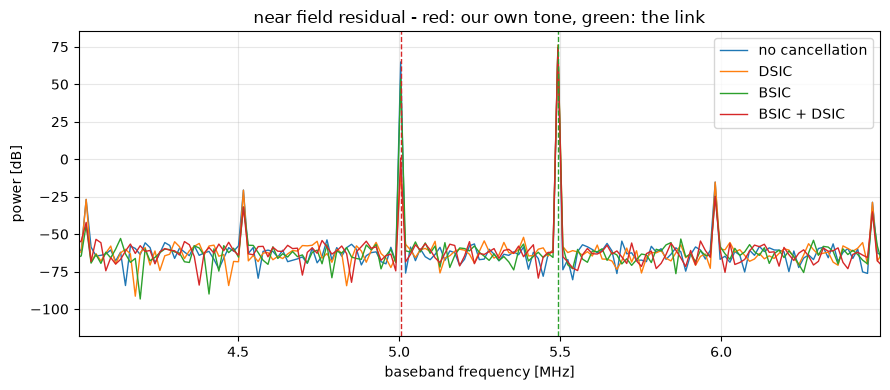

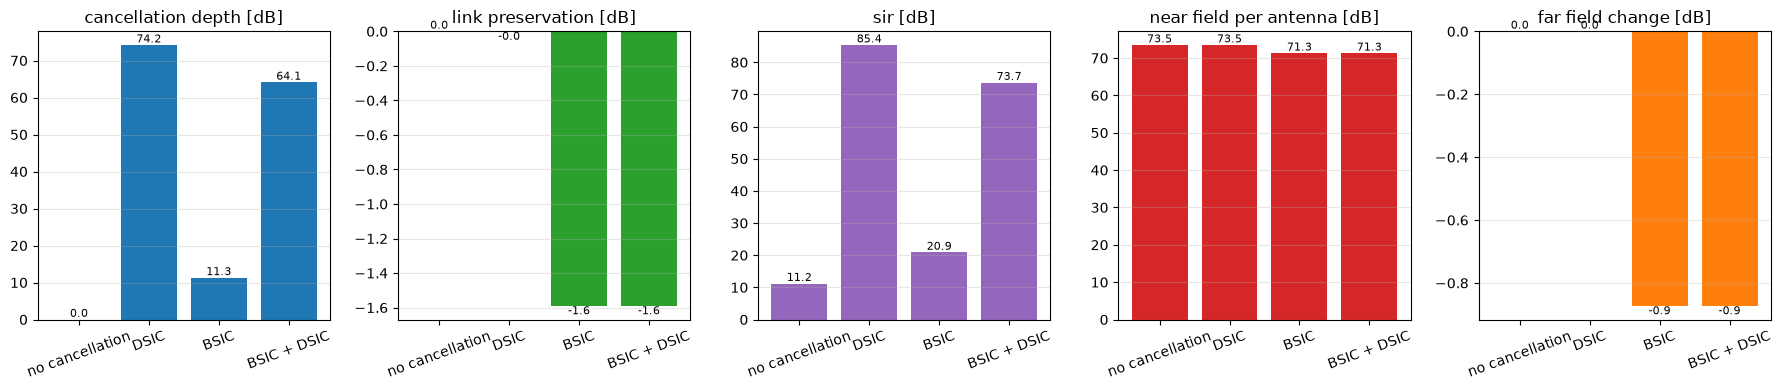

In [9]:
import matplotlib.pyplot as plt

def plot_stage_spectra(stages):
    """The combined near field residual of every stage, with both tone bins marked.

    A floor is added before the log so a stage that cancelled exactly does not
    blow it up.
    """
    frequency_mhz = np.fft.fftshift(np.fft.fftfreq(N_CAP, 1 / ADC_SR)) / 1e6
    figure, axis = plt.subplots(figsize=(9, 4))
    for name in STAGE_NAMES:
        spectrum = np.fft.fftshift(np.fft.fft(stages[name]["residual"])) / N_CAP
        power_db = 10 * np.log10(np.abs(spectrum) ** 2 + 1e-30)
        axis.plot(frequency_mhz, power_db, label=name, linewidth=1)
    axis.axvline(CW_TONE_0_MHZ, color="tab:red", linestyle="--", linewidth=1)
    axis.axvline(CW_TONE_1_MHZ, color="tab:green", linestyle="--", linewidth=1)
    axis.set_xlim(min(CW_TONE_0_MHZ, CW_TONE_1_MHZ) - 1,
                  max(CW_TONE_0_MHZ, CW_TONE_1_MHZ) + 1)
    axis.set_xlabel("baseband frequency [MHz]")
    axis.set_ylabel("power [dB]")
    axis.set_title("near field residual - red: our own tone, green: the link")
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()

def plot_stage_summary(rows):
    """Every metric in the table as its own panel of bars."""
    stage_names = [row["stage"] for row in rows]
    panels = [("cancellation depth [dB]", "depth_db", "tab:blue"),
              ("link preservation [dB]", "preservation_db", "tab:green"),
              ("sir [dB]", "sir_db", "tab:purple"),
              ("near field per antenna [dB]", "antenna_db", "tab:red"),
              ("far field change [dB]", "far_field_db", "tab:orange")]

    figure, axes = plt.subplots(1, len(panels), figsize=(3.6 * len(panels), 4))
    for axis, (title, key, color) in zip(axes, panels):
        values = [row[key] for row in rows]
        axis.bar(stage_names, values, color=color)
        axis.tick_params(axis="x", labelrotation=20)
        axis.set_title(title)
        axis.grid(axis="y", alpha=0.3)
        for position, value in enumerate(values):
            axis.text(position, value, "%.1f" % value, ha="center", fontsize=8,
                      va="bottom" if value >= 0 else "top")
    figure.tight_layout()

plot_stage_spectra(STAGES)
plot_stage_summary(RESULTS)
plt.show()

## 10. Save

| file | what it holds |
|---|---|
| `params.json` | every setting the run used, both tones included |
| `results.md` | the printed table, the BSIC weights and the DSIC model |
| `tx_signal.npz` | system 0's transmitted waveform, at the receive rate |
| `rx_signal.npz` | capture 1: one row per `ADCS_0` antenna, plus the far field stream |
| `clean_rx_signal.npz` | capture 6 combined and cancelled, one stream |

`rx_signal.npz` is what the antennas heard before any weight was applied;
`clean_rx_signal.npz` is what the receiver was left with once `nf_rx` and the
digital canceller had both run. Both still carry system 1's tone, which is the
point - the link is what survives.

The folder is emptied first, so nothing stale reads as a result of this run. Only
the files sitting directly in it.

In [10]:
def save_sic_run(stages, weights, rows):
    """Replace the sic folder with the settings, the report and the signals."""
    clear_dir(SIC_DIR)
    save_sic_params(SIC_DIR)
    save_results_report(SIC_DIR, rows, stages, weights)
    save_signals(SIC_DIR, stages)
    print("saved %s: %s" % (SIC_DIR, sorted(os.listdir(SIC_DIR))))

def save_sic_params(folder):
    """Record the settings the numbers came from, so a result can be traced back."""
    params = {"dacs_0": DACS_0, "adcs_0": ADCS_0,
              "dacs_1": DACS_1, "adcs_1": ADCS_1,
              "channels_dir": CHANNELS_DIR,
              "bsic_algorithm": BSIC_ALGORITHM,
              "dsic_algorithm": DSIC_ALGORITHM,
              "dac_nco": DAC_NCO, "dac_zone": DAC_ZONE,
              "adc_nco": ADC_NCO, "adc_zone": ADC_ZONE,
              "cw_tone_0_mhz": CW_TONE_0_MHZ, "cw_tone_1_mhz": CW_TONE_1_MHZ,
              "cw_amp": CW_AMP,
              "snr_db": SNR_DB,
              "bsic_max_gain": BSIC_MAX_GAIN,
              "side_1_gain": SIDE_1_GAIN,
              "max_phase_deg": MAX_PHASE_DEG,
              "dsic_taps": DSIC_TAPS, "dsic_mu": DSIC_MU,
              "dsic_train_n": DSIC_TRAIN_N,
              "n_cap": N_CAP, "dac_sr": DAC_SR, "adc_sr": ADC_SR}
    save_json_params(folder, params)

def save_results_report(folder, rows, stages, weights):
    """The table and every weight behind it, as the markdown that goes in the writeup."""
    lines = ["# One sided full duplex SIC run", "",
             "BSIC: `%s` - DSIC: `%s`" % (BSIC_ALGORITHM, DSIC_ALGORITHM), "",
             "System 0 transmits %.6f MHz, system 1 transmits %.6f MHz."
             % (CW_TONE_0_MHZ, CW_TONE_1_MHZ), ""]
    lines = lines + create_metrics_lines(rows)
    lines = lines + create_bsic_lines(weights)
    lines = lines + create_dsic_lines(stages)
    with open(os.path.join(folder, "results.md"), "w") as handle:
        handle.write("\n".join(lines) + "\n")

def create_metrics_lines(rows):
    """The printed result table, as a markdown table."""
    lines = ["## Results", "",
             "| stage | " + " | ".join(RESULT_HEADERS) + " |",
             "|---" * (len(RESULT_HEADERS) + 1) + "|"]
    for row in rows:
        values = " | ".join("%.2f" % row[header] for header in RESULT_HEADERS)
        lines.append("| %s | %s |" % (row["stage"], values))
    return lines + [""]

def create_bsic_lines(weights):
    """The transmit weights as the DACs take them, then the two receive combines.

    Gain and phase and not real and imaginary, because that is the pair the
    hardware is set with and the pair a person can check by eye.
    """
    lines = ["## BSIC weights - %s" % BSIC_ALGORITHM, "", "Transmit, per DAC:", "",
             "| DAC | gain | phase [deg] |", "|---|---|---|"]
    for dac in DACS_0:
        lines.append("| %d | %.4f | %+.3f |"
                     % (dac, BSIC_GAINS[dac], BSIC_PHASES[dac]))
    lines = lines + create_combine_lines("Near field combine, per ADC:",
                                        ADCS_0, weights["nf_rx"])
    lines = lines + create_combine_lines("Far field combine, per ADC:",
                                        ADCS_1, weights["ff_rx"])
    return lines + [""]

def create_combine_lines(title, adc_list, combine_weights):
    """One receive combiner as a table, magnitude and phase per ADC."""
    lines = ["", title, "", "| ADC | magnitude | phase [deg] |", "|---|---|---|"]
    for adc, value in zip(adc_list, combine_weights):
        lines.append("| %d | %.4f | %+.3f |"
                     % (adc, abs(value), np.degrees(np.angle(value))))
    return lines

def create_dsic_lines(stages):
    """The model the canceller settled on, whatever shape the algorithm returns.

    Taken from the BSIC + DSIC stage, the one that ends up on the bench. The wiener
    pair returns a filter and coefficients, so a column says which a row belongs to.
    """
    model = stages["BSIC + DSIC"]["dsic_model"]
    blocks = [("taps", model[0]), ("coeffs", model[1])] if isinstance(model, tuple) \
             else [("taps", model)]
    lines = ["## DSIC model, after BSIC - %s" % DSIC_ALGORITHM, "",
             "| block | index | magnitude | phase [deg] |", "|---|---|---|---|"]
    for name, values in blocks:
        for index, value in enumerate(values):
            lines.append("| %s | %d | %.6g | %+.3f |"
                         % (name, index, abs(value), np.degrees(np.angle(value))))
    return lines + [""]

def save_signals(folder, stages):
    """What was sent, what the antennas heard, and what the receiver was left with.

    Per antenna on the way in and one combined stream on the way out, because the
    receive beamformer sits between them.
    """
    np.savez(os.path.join(folder, "tx_signal.npz"), tx_signal=TX_REFERENCE)
    np.savez(os.path.join(folder, "rx_signal.npz"),
             rx_signal=stages["no cancellation"]["antennas"],
             far_field_signal=stages["no cancellation"]["far_field"])
    np.savez(os.path.join(folder, "clean_rx_signal.npz"),
             clean_rx_signal=stages["BSIC + DSIC"]["residual"])

save_sic_run(STAGES, BSIC_WEIGHTS, RESULTS)

saved output/sic: ['clean_rx_signal.npz', 'params.json', 'results.md', 'rx_signal.npz', 'tx_signal.npz']


## 11. Stop

Switch both transmitters off when you are done.

In [ ]:
OVERLAY.dacs_off()
print("dacs off")